# What do Big Five personality scores look like across countries, gender, and age?

The Open-Source Psychometrics Project has a massive public dataset of Big Five (OCEAN) personality responses.
I used a **scored** version of that dataset (`openpsych_data_scored.csv`) to explore a few questions:

### My questions

1. What do the **overall distributions** of the Big Five scores look like?
2. Do average Big Five scores differ by gender?
3. Do average Big Five scores differ by country?
4. Do scores change with age?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("openpsych_data_scored.csv")
df.head(), df.shape

(   race  age  engnat  gender  hand  source country  E1  E2  E3  ...   O   C  \
 0     3   53       1       1     1       1      US   4   4   5  ...  43  47   
 1    13   46       1       2     1       1      US   2   4   3  ...  26  42   
 2     1   14       2       2     1       1      PK   5   5   1  ...  45  49   
 3     3   19       2       2     1       1      RO   2   1   2  ...  41  26   
 4    11   25       2       2     1       2      US   3   5   3  ...  34  34   
 
     E   A   N  E_pct  A_pct  C_pct  N_pct  O_pct  
 0  44  46  49     93     85     97     99     70  
 1  22  35  29     20     27     86     50      2  
 2  35  38  14     68     42     98      3     81  
 3  22  37  17     20     37     16      8     58  
 4  34  44  30     64     76     52     54     20  
 
 [5 rows x 69 columns],
 (19719, 69))

In [2]:
df.columns

Index(['race', 'age', 'engnat', 'gender', 'hand', 'source', 'country', 'E1',
       'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'N1', 'N2', 'N3',
       'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10', 'A1', 'A2', 'A3', 'A4', 'A5',
       'A6', 'A7', 'A8', 'A9', 'A10', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7',
       'C8', 'C9', 'C10', 'O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9',
       'O10', 'race_cat', 'gender_cat', 'O', 'C', 'E', 'A', 'N', 'E_pct',
       'A_pct', 'C_pct', 'N_pct', 'O_pct'],
      dtype='str')

## Q1) What do the Big Five score distributions look like?

Before comparing groups, I wanted to see what the scores looked like overall, (tightly clustered, skewed, etc.)

In [5]:
score_cols = ["E", "A", "C", "N", "O"]          # raw summed scores (10–50)
# score_cols = ["E_pct","A_pct","C_pct","N_pct","O_pct"]  # optional: percentiles (0–100)

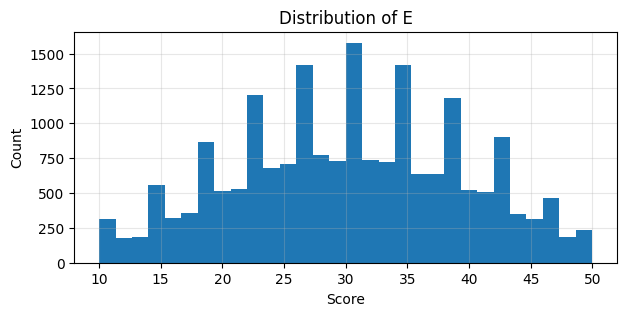

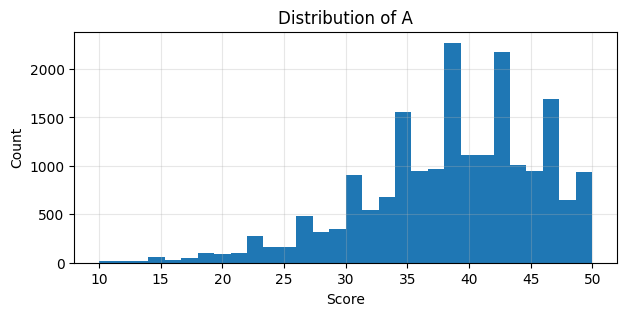

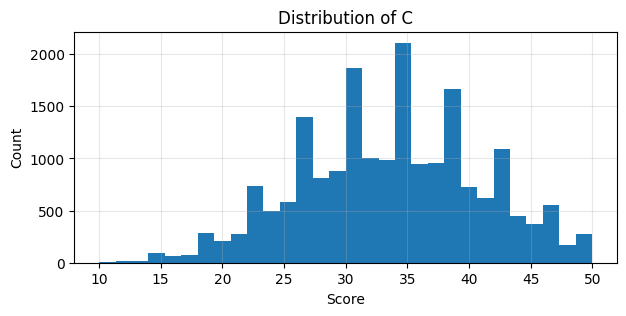

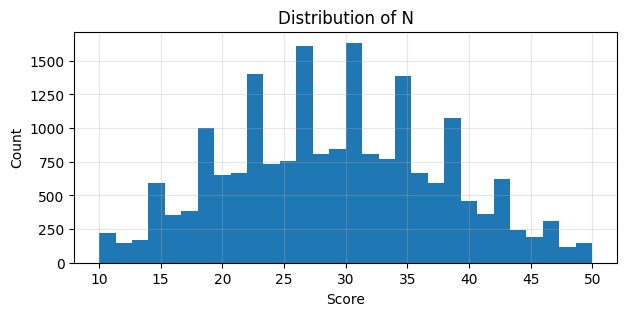

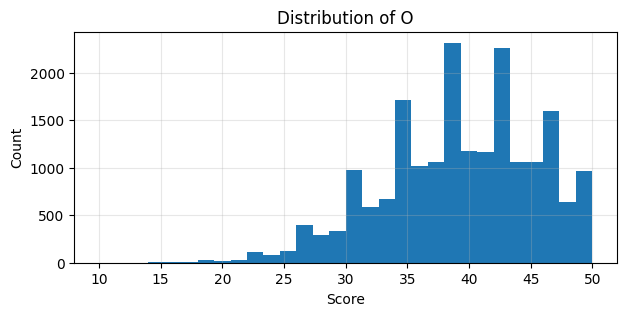

In [6]:
for col in score_cols:
    plt.figure(figsize=(7,3))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Score")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.show()

## Q2) Do scores differ by gender?

Next, I grouped respondents by gender and compared average trait scores.

In [9]:
gender_map = {1: "Male", 2: "Female", 3: "Other", 0: "Missing"}

df["gender_cat"] = df["gender"].map(gender_map)

gender_means = df.groupby("gender_cat")[score_cols].mean().round(2)
gender_counts = df["gender_cat"].value_counts()

print("Counts:")
display(gender_counts)

print("\nMeans:")
display(gender_means)

Counts:


gender_cat
Female     11985
Male        7608
Other        102
Missing       24
Name: count, dtype: int64


Means:


,E,A,C,N,O
gender_cat,,,,,
Female,30.53,39.68,33.65,27.89,38.57
Male,29.54,36.55,33.22,30.85,39.87
Missing,29.92,38.38,33.29,32.50,41.17
Other,24.34,35.28,31.39,25.91,41.55


## Q3) Do scores differ by country?

Because the dataset is for a lot of countries, I focused on the countries with the most responses, and then compared average trait scores across them.

In [11]:
if "country" in df.columns:
    top_countries = df["country"].value_counts().head(10).index.tolist()
    df_top = df[df["country"].isin(top_countries)].copy()

    country_means = df_top.groupby("country")[score_cols].mean().round(2)
    country_counts = df_top["country"].value_counts()
    country_means, country_counts

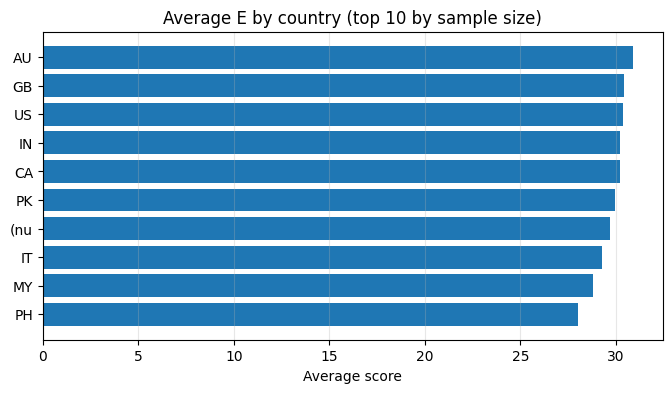

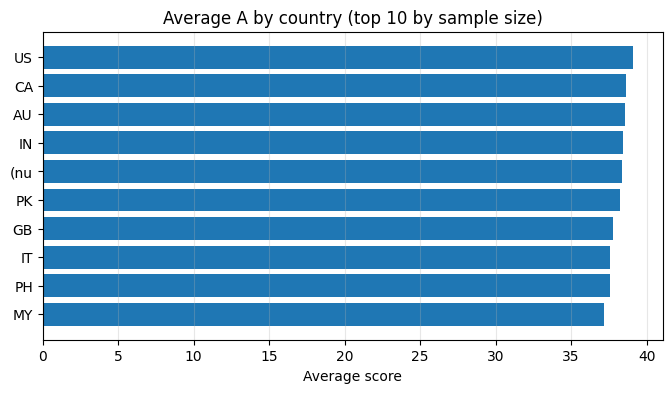

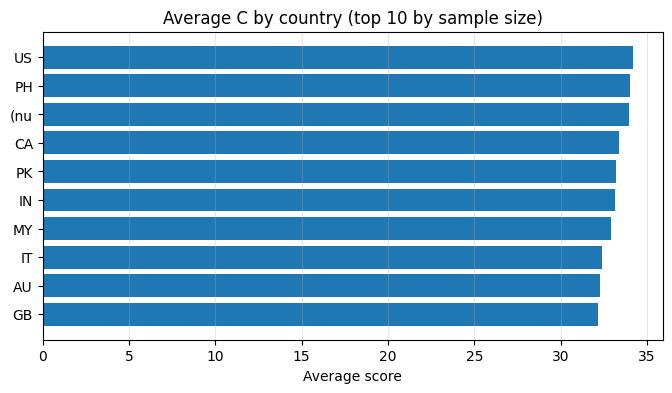

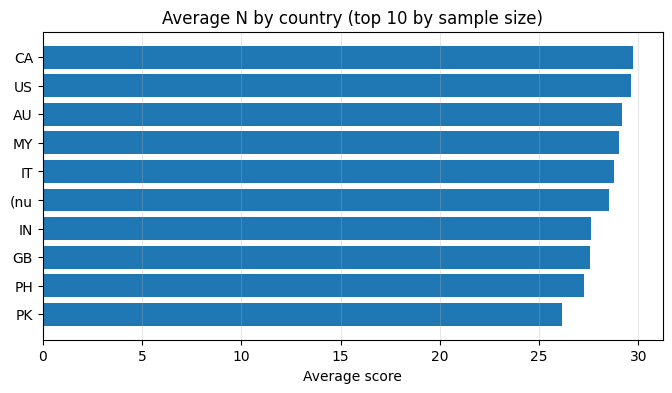

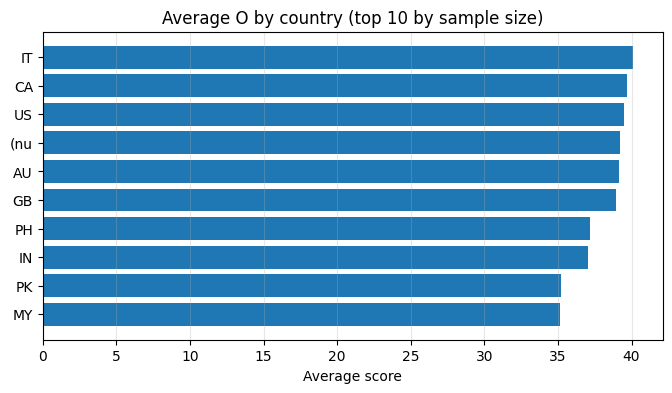

In [12]:
if "country" in df.columns:
    for col in score_cols:
        plt.figure(figsize=(8,4))
        means = df_top.groupby("country")[col].mean().sort_values()
        plt.barh(means.index, means.values)
        plt.title(f"Average {col} by country (top 10 by sample size)")
        plt.xlabel("Average score")
        plt.grid(True, axis="x", alpha=0.3)
        plt.show()

## Q4) How do scores change with age?

Age in this dataset is a bit messy as there are some unrealistic values that have been put in, so I filtered a reasonable range and looked at how average scores vary across age bands.

In [13]:
if "age" in df.columns:
    df_age = df.copy()
    df_age = df_age[(df_age["age"] >= 13) & (df_age["age"] <= 80)].copy()

    df_age["age_band"] = pd.cut(
        df_age["age"],
        bins=[13,18,25,35,45,55,65,80],
        include_lowest=True
    )

    age_means = df_age.groupby("age_band")[score_cols].mean().round(2)
    age_counts = df_age["age_band"].value_counts().sort_index()
    age_means, age_counts

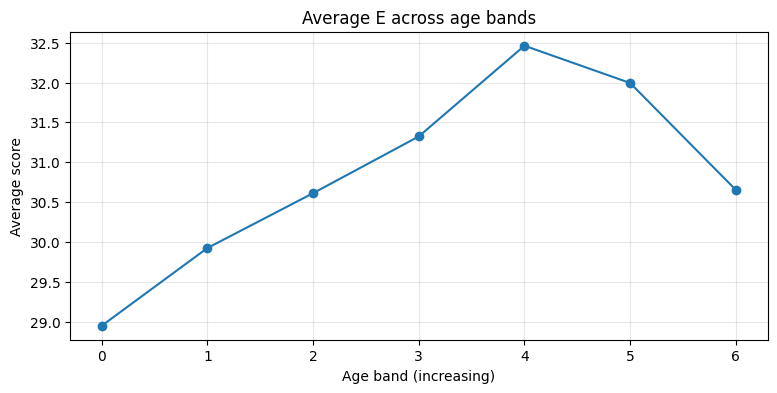

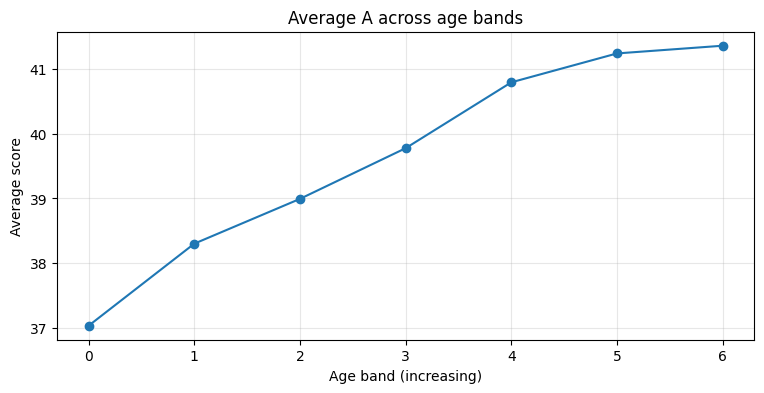

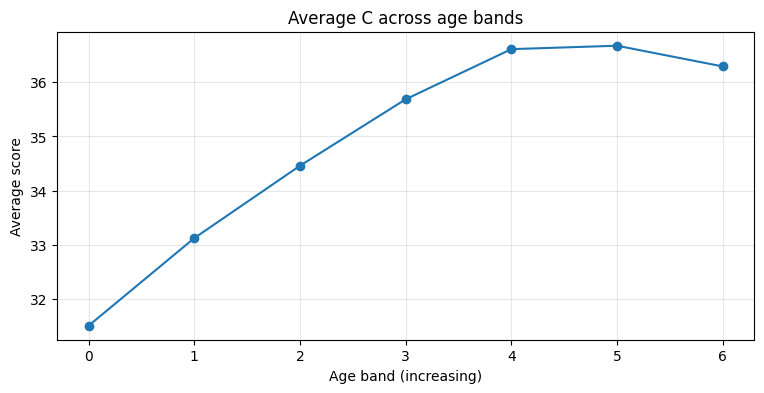

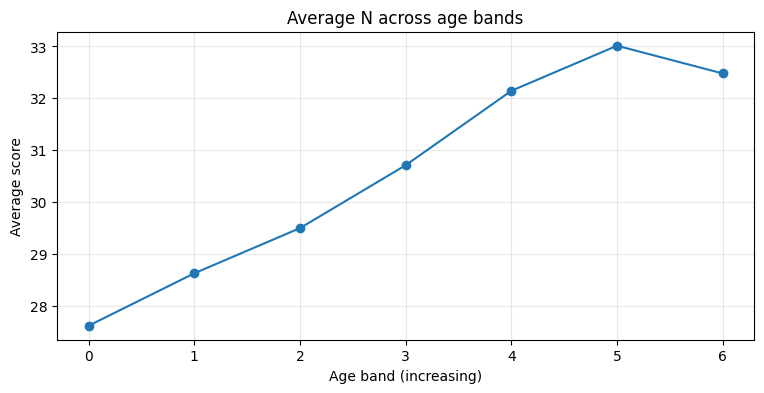

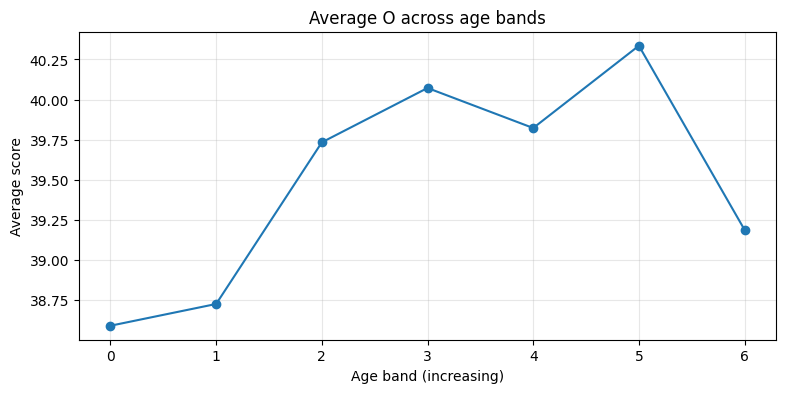

In [14]:
if "age_band" in df_age.columns:
    for col in score_cols:
        plt.figure(figsize=(9,4))
        means = df_age.groupby("age_band")[col].mean()
        plt.plot(range(len(means)), means.values, marker="o")
        plt.title(f"Average {col} across age bands")
        plt.xlabel("Age band (increasing)")
        plt.ylabel("Average score")
        plt.grid(True, alpha=0.3)
        plt.show()

## Final takeaways

The main points are:

The distributions are wide, meaning there’s a lot of natural variation person-to-person.

Group differences (gender/country/age) often exist, but the key question is whether they’re large relative to the overall spread.

In many cases, the overlap between groups is big and the typical person in one group often looks very similar to the typical person in another.